In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Libraries loaded successfully.


In [2]:
DATA_DIR = Path("../data")

files = {
    "COD": DATA_DIR / "cod.csv",
    "TN": DATA_DIR / "tn.csv",
    "TP": DATA_DIR / "tp.csv"
}

datasets = {}

for target_name, file_path in files.items():
    df = pd.read_csv(file_path)

    df["sampling_time"] = pd.to_datetime(df["sampling_time"])
    df = df.sort_values("sampling_time").reset_index(drop=True)

    datasets[target_name] = df

    print(
        target_name,
        df.shape,
        df["sampling_time"].min(),
        "to",
        df["sampling_time"].max()
    )

COD (6289, 24) 2022-07-07 01:00:00 to 2023-12-13 01:00:00
TN (6289, 24) 2022-07-07 01:00:00 to 2023-12-13 01:00:00
TP (6289, 24) 2022-07-07 01:00:00 to 2023-12-13 01:00:00


In [3]:
process_features = [
    col
    for col in datasets["COD"].columns
    if col not in ["sampling_time", "eff"]
]

print("Number of process features:", len(process_features))
print(process_features)

Number of process features: 22
['Q1', 'Q2', 'TCOD', 'TKN', 'TP', 'SNHx', 'Airflow1_1', 'Airflow1_2', 'Airflow2_1', 'Airflow2_2', 'PAC1', 'PAC2', 'PAC_HE', 'Reflux1_1', 'Reflux1_2', 'Reflux2_1', 'Reflux2_2', 'RAS1', 'RAS2', 'WAS1', 'WAS2', 'T']


这里的 shift(-1) 意思就是把下一行的 eff 拿过来作为当前这一行要预测的结果。

In [4]:
def create_ml_dataset(df, process_features):

    data = df.copy()

    # 当前 eff 作为一个输入变量
    data["current_eff"] = data["eff"]

    # 两小时后的 eff 作为预测目标
    data["future_eff"] = data["eff"].shift(-1)

    # 保存预测目标对应的时间
    data["target_time"] = data["sampling_time"].shift(-1)

    feature_columns = process_features + ["current_eff"]

    model_data = data[
        ["sampling_time", "target_time"] +
        feature_columns +
        ["future_eff"]
    ].dropna().copy()

    return model_data, feature_columns

按照时间划分训练集、验证集和测试集.最后 5% 的原始时间点作为最终测试集。剩下前面的数据，再按照时间顺序分成训练集和验证集。

In [5]:
def chronological_split(df, model_data):

    # 和 03 保持一致：
    # 原始数据最后 5% 的时间点作为最终测试目标
    test_start_idx = int(len(df) * 0.95)
    test_start_time = df["sampling_time"].iloc[test_start_idx]

    # 测试集按照 target_time 划分
    dev_data = model_data[
        model_data["target_time"] < test_start_time
    ].copy()

    test_data = model_data[
        model_data["target_time"] >= test_start_time
    ].copy()

    # development data 前 85% train，后 15% validation
    train_end = int(len(dev_data) * 0.85)

    train_data = dev_data.iloc[:train_end].copy()
    val_data = dev_data.iloc[train_end:].copy()

    return train_data, val_data, test_data

In [6]:
def evaluate_regression(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    r2 = r2_score(y_true, y_pred)

    relative_error = np.abs(
        (y_true - y_pred) / y_true
    )

    within_5 = np.mean(relative_error <= 0.05) * 100
    within_10 = np.mean(relative_error <= 0.10) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2,
        "Within ±5% (%)": within_5,
        "Within ±10% (%)": within_10
    }

In [7]:
def evaluate_regression(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    r2 = r2_score(y_true, y_pred)

    relative_error = np.abs(
        (y_true - y_pred) / y_true
    )

    within_5 = np.mean(relative_error <= 0.05) * 100
    within_10 = np.mean(relative_error <= 0.10) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2,
        "Within ±5% (%)": within_5,
        "Within ±10% (%)": within_10
    }

建立三个模型

In [8]:
def build_models():

    models = {

        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0))
        ]),

        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ),

        "XGBoost": XGBRegressor(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    }

    return models

In [9]:
all_results = []
all_predictions = {}

for target_name, df in datasets.items():

    print("=" * 70)
    print(target_name)
    print("=" * 70)

    model_data, feature_columns = create_ml_dataset(
        df,
        process_features
    )

    train_data, val_data, test_data = chronological_split(
        df,
        model_data
    )

    print("Train:", len(train_data))
    print("Validation:", len(val_data))
    print("Test:", len(test_data))

    X_train = train_data[feature_columns]
    y_train = train_data["future_eff"]

    X_val = val_data[feature_columns]
    y_val = val_data["future_eff"]

    X_test = test_data[feature_columns]
    y_test = test_data["future_eff"]

    models = build_models()

    all_predictions[target_name] = {}

    for model_name, model in models.items():

        print("\nTraining:", model_name)

        model.fit(X_train, y_train)

        # validation
        val_pred = model.predict(X_val)
        val_metrics = evaluate_regression(
            y_val.values,
            val_pred
        )

        # final test
        test_pred = model.predict(X_test)
        test_metrics = evaluate_regression(
            y_test.values,
            test_pred
        )

        print(
            "Validation MAE:",
            round(val_metrics["MAE"], 4)
        )

        print(
            "Test MAE:",
            round(test_metrics["MAE"], 4)
        )

        print(
            "Test R2:",
            round(test_metrics["R2"], 4)
        )

        result = {
            "Target": target_name,
            "Model": model_name,
            **test_metrics
        }

        all_results.append(result)

        all_predictions[target_name][model_name] = {
            "time": test_data["target_time"].values,
            "actual": y_test.values,
            "predicted": test_pred
        }

COD
Train: 5077
Validation: 896
Test: 315

Training: Ridge
Validation MAE: 0.0866
Test MAE: 0.0667
Test R2: 0.9693

Training: Random Forest
Validation MAE: 0.0937
Test MAE: 0.0768
Test R2: 0.9633

Training: XGBoost
Validation MAE: 0.1753
Test MAE: 0.2636
Test R2: 0.7119
TN
Train: 5077
Validation: 896
Test: 315

Training: Ridge
Validation MAE: 0.1312
Test MAE: 0.1427
Test R2: 0.9676

Training: Random Forest
Validation MAE: 0.151
Test MAE: 0.1225
Test R2: 0.9725

Training: XGBoost
Validation MAE: 0.187
Test MAE: 0.3696
Test R2: 0.8128
TP
Train: 5077
Validation: 896
Test: 315

Training: Ridge
Validation MAE: 0.0153
Test MAE: 0.0161
Test R2: 0.918

Training: Random Forest
Validation MAE: 0.0142
Test MAE: 0.0162
Test R2: 0.9069

Training: XGBoost
Validation MAE: 0.0185
Test MAE: 0.022
Test R2: 0.8537


In [10]:
results_df = pd.DataFrame(all_results)

results_df

,Target,Model,MAE,RMSE,MAPE (%),R2,Within ±5% (%),Within ±10% (%)
0,COD,Ridge,0.066687,0.093940,0.882209,0.969325,99.682540,100.000000
1,COD,Random Forest,0.076799,0.102738,1.014018,0.963309,100.000000,100.000000
2,COD,XGBoost,0.263579,0.287882,3.589798,0.711918,80.317460,100.000000
3,TN,Ridge,0.142656,0.169348,1.250942,0.967636,100.000000,100.000000
4,TN,Random Forest,0.122480,0.156059,1.081419,0.972516,100.000000,100.000000
5,TN,XGBoost,0.369649,0.407299,3.191817,0.812787,91.746032,100.000000
6,TP,Ridge,0.016141,0.021915,4.175528,0.917973,71.428571,93.015873
7,TP,Random Forest,0.016206,0.023353,4.230379,0.906853,71.428571,90.793651
8,TP,XGBoost,0.021955,0.029272,5.341409,0.853655,59.047619,87.301587


In [11]:
results_df = pd.DataFrame(all_results)

results_df

,Target,Model,MAE,RMSE,MAPE (%),R2,Within ±5% (%),Within ±10% (%)
0,COD,Ridge,0.066687,0.093940,0.882209,0.969325,99.682540,100.000000
1,COD,Random Forest,0.076799,0.102738,1.014018,0.963309,100.000000,100.000000
2,COD,XGBoost,0.263579,0.287882,3.589798,0.711918,80.317460,100.000000
3,TN,Ridge,0.142656,0.169348,1.250942,0.967636,100.000000,100.000000
4,TN,Random Forest,0.122480,0.156059,1.081419,0.972516,100.000000,100.000000
5,TN,XGBoost,0.369649,0.407299,3.191817,0.812787,91.746032,100.000000
6,TP,Ridge,0.016141,0.021915,4.175528,0.917973,71.428571,93.015873
7,TP,Random Forest,0.016206,0.023353,4.230379,0.906853,71.428571,90.793651
8,TP,XGBoost,0.021955,0.029272,5.341409,0.853655,59.047619,87.301587


找每个目标表现最好的机器学习模型

In [12]:
best_models = (
    results_df
    .sort_values("MAE")
    .groupby("Target", as_index=False)
    .first()
)

best_models

,Target,Model,MAE,RMSE,MAPE (%),R2,Within ±5% (%),Within ±10% (%)
0,COD,Ridge,0.066687,0.093940,0.882209,0.969325,99.682540,100.000000
1,TN,Random Forest,0.122480,0.156059,1.081419,0.972516,100.000000,100.000000
2,TP,Ridge,0.016141,0.021915,4.175528,0.917973,71.428571,93.015873


画真实值和预测值

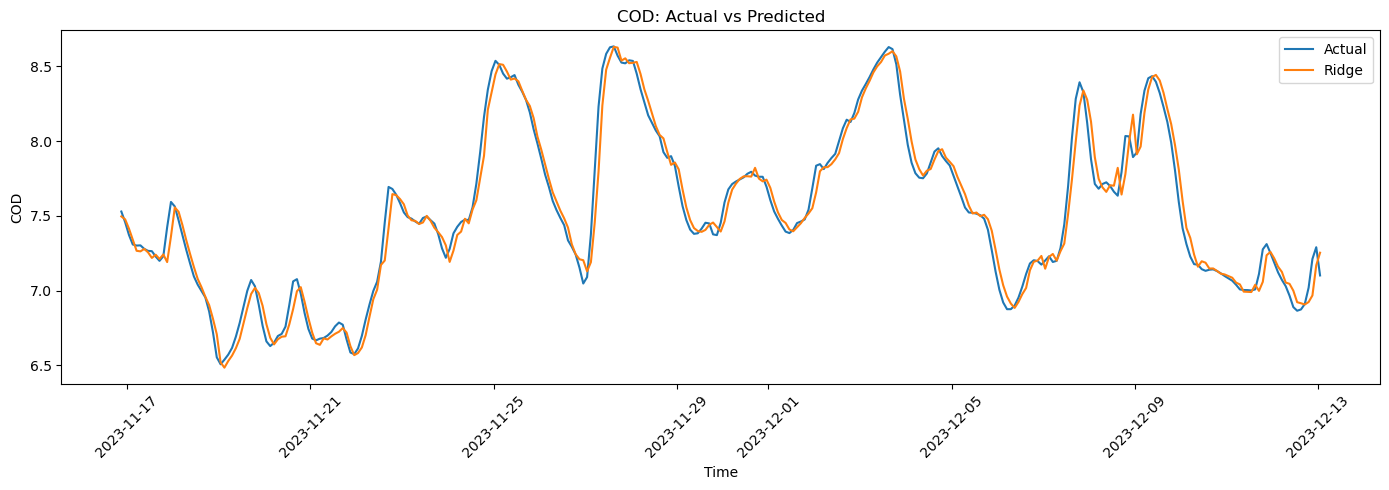

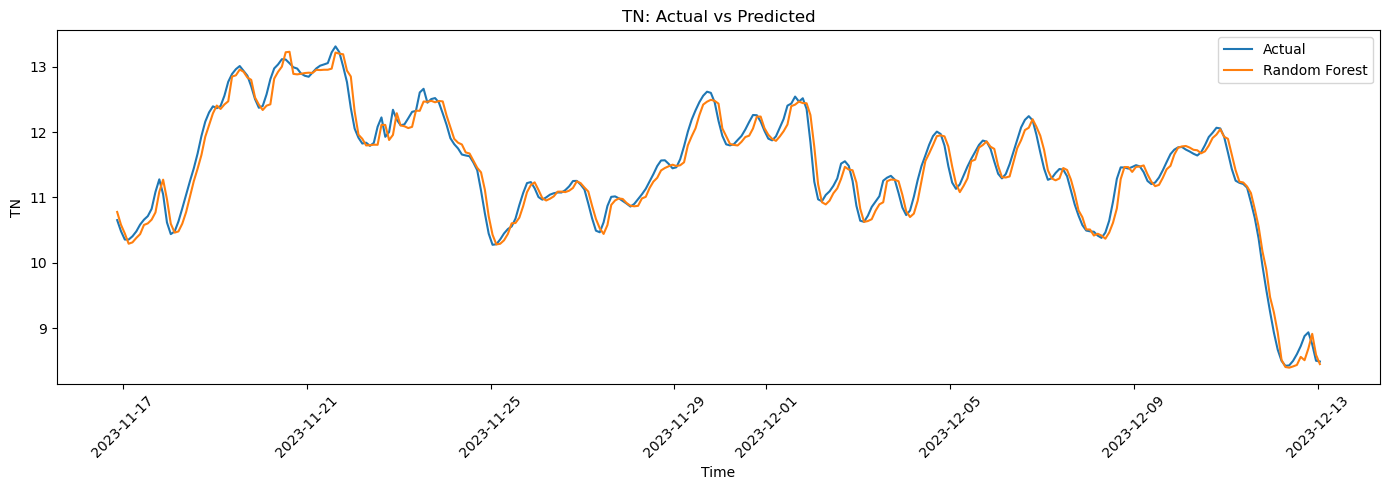

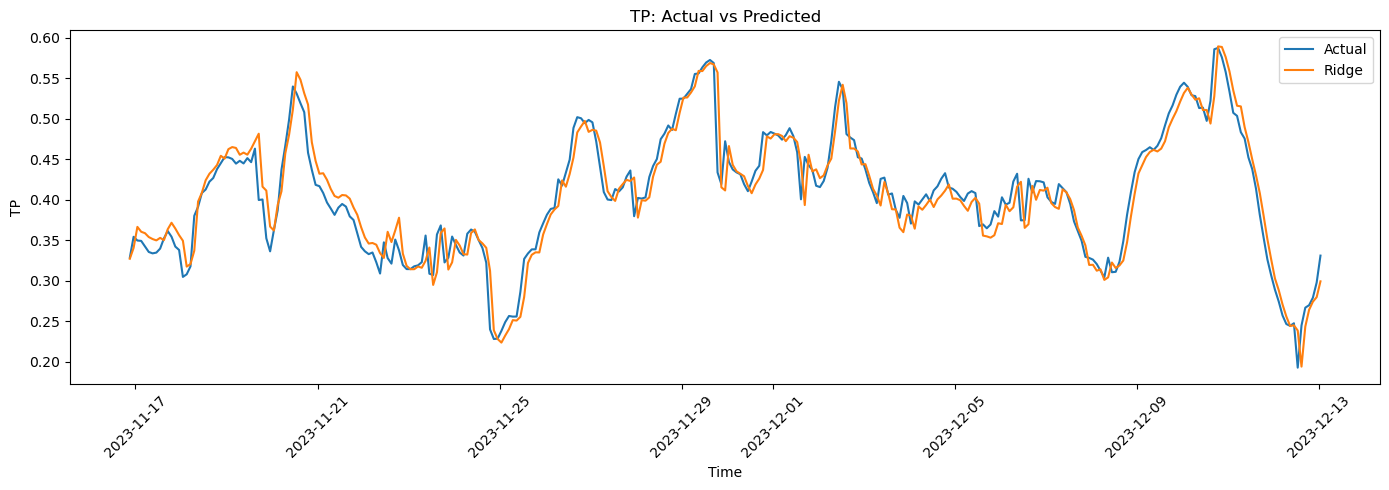

In [13]:
for target_name in ["COD", "TN", "TP"]:

    target_results = results_df[
        results_df["Target"] == target_name
    ]

    best_model_name = (
        target_results
        .sort_values("MAE")
        .iloc[0]["Model"]
    )

    prediction_data = all_predictions[
        target_name
    ][best_model_name]

    plt.figure(figsize=(14, 5))

    plt.plot(
        prediction_data["time"],
        prediction_data["actual"],
        label="Actual"
    )

    plt.plot(
        prediction_data["time"],
        prediction_data["predicted"],
        label=best_model_name
    )

    plt.title(
        f"{target_name}: Actual vs Predicted"
    )

    plt.xlabel("Time")
    plt.ylabel(target_name)

    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

分析高变化时段

In [14]:
# ============================================================
# High-Change Analysis
#
# 与 03_baseline 使用完全相同的定义：
#
# 1. 原始数据前 95% = development period
# 2. development period 前 85% = training period
# 3. 只使用 training period 的 eff 计算两小时绝对变化
# 4. training absolute change 的 95th percentile
#    作为 High-Change threshold
# 5. 所有模型使用完全相同的 test high-change observations
# ============================================================

high_change_results = []
high_change_thresholds = {}

for target_name, df in datasets.items():

    # --------------------------------------------------------
    # 1. 与 03 完全一致地划分原始时间序列
    # --------------------------------------------------------

    split_idx = int(len(df) * 0.95)

    train_full = df.iloc[:split_idx].copy()
    test_full = df.iloc[split_idx:].copy()

    # 03 中的 training data
    train_end = int(len(train_full) * 0.85)
    train_df = train_full.iloc[:train_end].copy()

    # --------------------------------------------------------
    # 2. 使用 training data 计算 High-Change threshold
    # --------------------------------------------------------

    train_abs_change = (
        train_df["eff"]
        .diff()
        .abs()
        .dropna()
    )

    threshold = train_abs_change.quantile(0.95)

    high_change_thresholds[target_name] = threshold

    # --------------------------------------------------------
    # 3. 重新获得 04 的 test_data
    # --------------------------------------------------------

    model_data, feature_columns = create_ml_dataset(
        df,
        process_features
    )

    train_data, val_data, test_data = chronological_split(
        df,
        model_data
    )

    # --------------------------------------------------------
    # 4. Test 中真实发生的两小时变化
    #
    # future_eff  = t+2h 的真实值
    # current_eff = t 时刻真实值
    # --------------------------------------------------------

    actual_change = np.abs(
        test_data["future_eff"].values -
        test_data["current_eff"].values
    )

    high_change_mask = actual_change > threshold

    print(
        target_name,
        "threshold:",
        round(threshold, 6),
        "high-change observations:",
        high_change_mask.sum()
    )

    # --------------------------------------------------------
    # 5. 所有 ML 模型在完全相同的 High-Change points 上评估
    # --------------------------------------------------------

    y_high = test_data["future_eff"].values[
        high_change_mask
    ]

    for model_name, pred_data in all_predictions[
        target_name
    ].items():

        pred_high = pred_data["predicted"][
            high_change_mask
        ]

        if len(y_high) == 0:
            continue

        metrics = evaluate_regression(
            y_high,
            pred_high
        )

        high_change_results.append({
            "Target": target_name,
            "Model": model_name,
            "N": len(y_high),
            **metrics
        })


high_change_df = pd.DataFrame(high_change_results)

high_change_df

COD threshold: 0.282703 high-change observations: 4
TN threshold: 0.341529 high-change observations: 10
TP threshold: 0.06036 high-change observations: 5


,Target,Model,N,MAE,RMSE,MAPE (%),R2,Within ±5% (%),Within ±10% (%)
0,COD,Ridge,4,0.313400,0.326448,3.954025,-0.068637,75.0,100.0
1,COD,Random Forest,4,0.350010,0.352662,4.439929,-0.247153,100.0,100.0
2,COD,XGBoost,4,0.111088,0.114908,1.420421,0.867596,100.0,100.0
3,TN,Ridge,10,0.322424,0.340240,2.890658,0.850516,100.0,100.0
4,TN,Random Forest,10,0.387976,0.397262,3.478152,0.796212,100.0,100.0
5,TN,XGBoost,10,0.286522,0.402384,2.487524,0.790923,70.0,100.0
6,TP,Ridge,5,0.075758,0.080492,20.071379,0.472187,0.0,20.0
7,TP,Random Forest,5,0.077924,0.083013,20.023215,0.438603,0.0,0.0
8,TP,XGBoost,5,0.073109,0.075975,19.287280,0.529762,0.0,20.0


In [15]:
high_change_df = pd.DataFrame(
    high_change_results
)

high_change_df.sort_values(
    ["Target", "MAE"]
).reset_index(drop=True)

,Target,Model,N,MAE,RMSE,MAPE (%),R2,Within ±5% (%),Within ±10% (%)
0,COD,XGBoost,4,0.111088,0.114908,1.420421,0.867596,100.0,100.0
1,COD,Ridge,4,0.313400,0.326448,3.954025,-0.068637,75.0,100.0
2,COD,Random Forest,4,0.350010,0.352662,4.439929,-0.247153,100.0,100.0
3,TN,XGBoost,10,0.286522,0.402384,2.487524,0.790923,70.0,100.0
4,TN,Ridge,10,0.322424,0.340240,2.890658,0.850516,100.0,100.0
5,TN,Random Forest,10,0.387976,0.397262,3.478152,0.796212,100.0,100.0
6,TP,XGBoost,5,0.073109,0.075975,19.287280,0.529762,0.0,20.0
7,TP,Ridge,5,0.075758,0.080492,20.071379,0.472187,0.0,20.0
8,TP,Random Forest,5,0.077924,0.083013,20.023215,0.438603,0.0,0.0


查看变量重要性

In [16]:
feature_importance_results = {}

for target_name, df in datasets.items():

    model_data, feature_columns = create_ml_dataset(
        df,
        process_features
    )

    train_data, val_data, test_data = chronological_split(
        df,
        model_data
    )

    # 最终模型开发阶段使用 train + validation
    development_data = pd.concat(
        [train_data, val_data]
    )

    X_dev = development_data[feature_columns]
    y_dev = development_data["future_eff"]

    models = build_models()

    for model_name in ["Random Forest", "XGBoost"]:

        model = models[model_name]

        model.fit(X_dev, y_dev)

        importance = pd.DataFrame({
            "Feature": feature_columns,
            "Importance": model.feature_importances_
        })

        importance = importance.sort_values(
            "Importance",
            ascending=False
        ).reset_index(drop=True)

        feature_importance_results[
            (target_name, model_name)
        ] = importance

        print("\n", target_name, "-", model_name)
        display(importance.head(10))


 COD - Random Forest


,Feature,Importance
0,current_eff,0.997027
1,TCOD,0.000586
2,TP,0.000188
3,Q1,0.000188
4,Q2,0.000171
5,TKN,0.000163
6,Reflux1_1,0.000153
7,SNHx,0.000148
8,Reflux2_2,0.000146
9,Reflux2_1,0.000124



 COD - XGBoost


,Feature,Importance
0,current_eff,0.633048
1,TCOD,0.094949
2,RAS1,0.051579
3,PAC2,0.050673
4,T,0.040321
5,RAS2,0.040070
6,PAC1,0.021795
7,Airflow2_1,0.019801
8,PAC_HE,0.017976
9,WAS2,0.010295



 TN - Random Forest


...

,Feature,Importance
0,current_eff,0.699925
1,T,0.083865
2,PAC_HE,0.051065
3,PAC2,0.039357
4,WAS2,0.020298
5,Q1,0.014642
6,RAS1,0.014511
7,SNHx,0.014163
8,Q2,0.009856
9,TCOD,0.008383



 TP - Random Forest


,Feature,Importance
0,current_eff,0.993330
1,WAS2,0.001068
2,Reflux1_2,0.000582
3,Reflux2_1,0.000555
4,Reflux2_2,0.000453
5,PAC_HE,0.000411
6,Q1,0.000353
7,Q2,0.000349
8,TP,0.000325
9,WAS1,0.000316



 TP - XGBoost


,Feature,Importance
0,current_eff,0.487357
1,PAC2,0.260817
2,PAC1,0.135477
3,WAS1,0.018250
4,T,0.016943
5,PAC_HE,0.014976
6,RAS1,0.012369
7,Airflow2_2,0.010092
8,Reflux2_1,0.008284
9,WAS2,0.007137


In [17]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

results_df.to_csv(
    RESULTS_DIR / "ml_model_results.csv",
    index=False
)

high_change_df.to_csv(
    RESULTS_DIR / "ml_high_change_results.csv",
    index=False
)

print("Results saved.")

Results saved.
